# CostGrow Ensemble Experiment

Run `downscale_costGrow_xr` across a full parameter matrix of `distance_fill` and `distance_fill_method`, then summarize runtime and validation metrics.


## 1) Imports and Paths

In [1]:
import os
import sys
import time
import logging
import itertools
import traceback
import multiprocessing as mp
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
import rasterio
import matplotlib
import matplotlib.pyplot as plt
import scipy

from fdsc.alg.costGrow import downscale_costGrow_xr
from misc.valid import (
    build_bilinear_depth_baseline,
    build_metrics_table,
    wse_to_depth_m,
    plot_hist_raster_grid,
)


/opt/conda/envs/dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
REPO_DIR = Path.cwd().resolve()
if not (REPO_DIR / "tests").exists() and (REPO_DIR.parent / "tests").exists():
    REPO_DIR = REPO_DIR.parent

BASE_DIR = REPO_DIR / "tests" / "data" / "bryantTechnicalNoteResolution2024"
OUT_DIR = REPO_DIR / "misc" / "_outputs" / "CostGrow_experiment"
RUN_DIR = OUT_DIR / "ensemble_runs"
RUN_DIR.mkdir(parents=True, exist_ok=True)

INPUT_DEM_FINE_FP = BASE_DIR / "dem_04m.tif"
INPUT_WSE_COARSE_FP = BASE_DIR / "wse_32m.tif"
REFERENCE_WSE_FINE_FP = BASE_DIR / "wse_04m.tif"

print(f"REPO_DIR:\n    {REPO_DIR}")
print(f"BASE_DIR:\n    {BASE_DIR}")
print(f"OUT_DIR:\n    {OUT_DIR}")
print(f"RUN_DIR:\n    {RUN_DIR}")
print(f"dem exists: {INPUT_DEM_FINE_FP.exists()}")
print(f"wse coarse exists: {INPUT_WSE_COARSE_FP.exists()}")
print(f"wse reference exists: {REFERENCE_WSE_FINE_FP.exists()}")


REPO_DIR:
    /workspace
BASE_DIR:
    /workspace/tests/data/bryantTechnicalNoteResolution2024
OUT_DIR:
    /workspace/misc/_outputs/CostGrow_experiment
RUN_DIR:
    /workspace/misc/_outputs/CostGrow_experiment/ensemble_runs
dem exists: True
wse coarse exists: True
wse reference exists: True


## 2) Version and File Diagnostics

In [3]:
print(f"python: {sys.version.split()[0]}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print(f"xarray: {xr.__version__}")
print(f"rioxarray: {rioxarray.__version__}")
print(f"rasterio: {rasterio.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"scipy: {scipy.__version__}")


def file_stats(fp: Path):
    st = fp.stat()
    with rasterio.open(fp) as ds:
        return {
            "file": fp.name,
            "size_mb": round(st.st_size / (1024**2), 3),
            "shape": (ds.height, ds.width),
            "crs": str(ds.crs),
            "res": ds.res,
            "nodata": ds.nodata,
            "bounds": tuple(round(v, 3) for v in ds.bounds),
            "dtype": ds.dtypes[0],
        }


stats_l = [
    file_stats(INPUT_DEM_FINE_FP),
    file_stats(INPUT_WSE_COARSE_FP),
    file_stats(REFERENCE_WSE_FINE_FP),
]
print("input file stats:")
for d in stats_l:
    print(
        f"  {d['file']}: size_mb={d['size_mb']}, shape={d['shape']}, crs={d['crs']}, "
        f"res={d['res']}, nodata={d['nodata']}, dtype={d['dtype']}"
    )


python: 3.12.12
numpy: 2.4.2
pandas: 3.0.1
xarray: 2025.11.0
rioxarray: 0.21.0
rasterio: 1.5.0
matplotlib: 3.10.8
scipy: 1.17.0
input file stats:
  dem_04m.tif: size_mb=10.596, shape=(1664, 3360), crs=EPSG:4647, res=(4.0, 4.0), nodata=-9999.0, dtype=float32
  wse_32m.tif: size_mb=0.051, shape=(208, 420), crs=EPSG:4647, res=(32.0, 32.0), nodata=-9999.0, dtype=float32
  wse_04m.tif: size_mb=2.164, shape=(1664, 3360), crs=EPSG:4647, res=(4.0, 4.0), nodata=-9999.0, dtype=float32


## 3) Load Input Rasters

In [4]:
def load_da(fp: Path, nodata=-9999.0) -> xr.DataArray:
    da = rioxarray.open_rasterio(fp, masked=False).squeeze().compute().rio.write_nodata(nodata)
    return da.where(da != nodata, np.nan)


# Load base rasters used in all ensemble members.
dem_fine_xr = load_da(INPUT_DEM_FINE_FP)
wse_coarse_xr = load_da(INPUT_WSE_COARSE_FP)
wse_reference_xr = load_da(REFERENCE_WSE_FINE_FP)

print(f"dem_fine_xr shape={dem_fine_xr.shape}, res={dem_fine_xr.rio.resolution()}, crs={dem_fine_xr.rio.crs}")
print(f"wse_coarse_xr shape={wse_coarse_xr.shape}, res={wse_coarse_xr.rio.resolution()}, crs={wse_coarse_xr.rio.crs}")
print(f"wse_reference_xr shape={wse_reference_xr.shape}, res={wse_reference_xr.rio.resolution()}, crs={wse_reference_xr.rio.crs}")

print(f"dem wet count: {int(dem_fine_xr.notnull().sum())}")
print(f"coarse wse wet count: {int(wse_coarse_xr.notnull().sum())}")
print(f"reference wse wet count: {int(wse_reference_xr.notnull().sum())}")


dem_fine_xr shape=(1664, 3360), res=(4.0, -4.0), crs=EPSG:4647
wse_coarse_xr shape=(208, 420), res=(32.0, -32.0), crs=EPSG:4647
wse_reference_xr shape=(1664, 3360), res=(4.0, -4.0), crs=EPSG:4647
dem wet count: 5591040
coarse wse wet count: 6907
reference wse wet count: 473710


## 4) Parameter Matrix

In [5]:
# Full simulation-style matrix over distance fill options.
DISTANCE_FILL_OPTIONS = [
    "neutral",
    "terrain_penalty",
]

# Candidate scipy.ndimage distance transform methods exposed by CostGrow.
DISTANCE_FILL_METHOD_OPTIONS = [
    "distance_transform_cdt",
    "distance_transform_edt",
    #"distance_transform_bf",
]

ensemble_plan_df = pd.DataFrame(
    list(itertools.product(DISTANCE_FILL_OPTIONS, DISTANCE_FILL_METHOD_OPTIONS)),
    columns=["distance_fill", "distance_fill_method"],
)
ensemble_plan_df["run_name"] = [
    f"{dfill}|{dmethod}" for dfill, dmethod in ensemble_plan_df[["distance_fill", "distance_fill_method"]].to_numpy()
]

print(f"planned runs: {len(ensemble_plan_df)}")
ensemble_plan_df


planned runs: 4


,distance_fill,distance_fill_method,run_name
0,neutral,distance_transform_cdt,neutral|distance_transform_cdt
1,neutral,distance_transform_edt,neutral|distance_transform_edt
2,terrain_penalty,distance_transform_cdt,terrain_penalty|distance_transform_cdt
3,terrain_penalty,distance_transform_edt,terrain_penalty|distance_transform_edt


## 5) Run Ensemble and Build Metrics

In [6]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(name)s: %(message)s")
logger = logging.getLogger("costgrow_ensemble")

# Validation thresholds shared across all runs.
RMSE_WET_THRESH_M = 0.5
CSI_THRESH_M = 0.01

# Hard timeout per combination so slow methods are still attempted but bounded.
MAX_RUN_SECONDS = 120

# Build shared validation arrays once.
dem_valid = np.isfinite(dem_fine_xr.data)

dem_profile = {
    "height": int(dem_fine_xr.shape[0]),
    "width": int(dem_fine_xr.shape[1]),
    "transform": dem_fine_xr.rio.transform(),
    "crs": dem_fine_xr.rio.crs,
    "nodata": dem_fine_xr.rio.nodata,
}

wse_profile = {
    "height": int(wse_coarse_xr.shape[0]),
    "width": int(wse_coarse_xr.shape[1]),
    "transform": wse_coarse_xr.rio.transform(),
    "crs": wse_coarse_xr.rio.crs,
    "nodata": wse_coarse_xr.rio.nodata,
}

wse_bilinear, bilinear_depth = build_bilinear_depth_baseline(
    lores_wse_arr=wse_coarse_xr.data,
    lores_wse_profile=wse_profile,
    dem_profile=dem_profile,
    dem_arr=dem_fine_xr.data,
    domain_mask=dem_valid,
)

valid_depth = wse_to_depth_m(wse_reference_xr.data, dem_fine_xr.data, dem_valid)


def _combo_worker(queue, dem_fp, wse_fp, distance_fill, distance_fill_method, run_name, output_fp):
    """Run one CostGrow combination in a separate process and persist WSE output."""
    try:
        local_logger = logging.getLogger(f"costgrow_worker.{run_name.replace('|', '_')}")
        local_logger.setLevel(logging.WARNING)

        dem_local = load_da(Path(dem_fp))
        wse_local = load_da(Path(wse_fp))

        run_wall_start = time.perf_counter()
        wse_downscaled_xr, meta_d = downscale_costGrow_xr(
            dem_local,
            wse_local,
            logger=local_logger,
            distance_fill=distance_fill,
            distance_fill_method=distance_fill_method,
        )
        wall_seconds = time.perf_counter() - run_wall_start

        wse_pred = np.where(np.isfinite(wse_downscaled_xr.data), wse_downscaled_xr.data, np.nan).astype("float64")
        np.save(output_fp, wse_pred)

        queue.put(
            {
                "status": "ok",
                "wall_seconds": wall_seconds,
                "wet_cell_count": int(np.isfinite(wse_pred).sum()),
                "meta_key_count": int(len(meta_d)),
                "output_fp": str(output_fp),
                "error": "",
            }
        )

    except Exception as e:
        queue.put(
            {
                "status": "failed",
                "wall_seconds": np.nan,
                "wet_cell_count": np.nan,
                "meta_key_count": np.nan,
                "output_fp": "",
                "error": f"{repr(e)} | traceback={traceback.format_exc(limit=1)}",
            }
        )


runtime_records = []
pred_depth_by_name = {
    "Bilinear": bilinear_depth,
}
pred_wse_by_name = {
    "Bilinear": np.where(np.isfinite(wse_bilinear), wse_bilinear, np.nan),
}

ctx = mp.get_context("fork")

for row in ensemble_plan_df.itertuples(index=False):
    run_name = row.run_name
    safe_name = run_name.replace("|", "__").replace("/", "_")
    output_fp = RUN_DIR / f"{safe_name}_wse.npy"

    queue = ctx.Queue()
    proc = ctx.Process(
        target=_combo_worker,
        args=(
            queue,
            str(INPUT_DEM_FINE_FP),
            str(INPUT_WSE_COARSE_FP),
            row.distance_fill,
            row.distance_fill_method,
            run_name,
            str(output_fp),
        ),
    )

    wall_start = time.perf_counter()
    proc.start()
    proc.join(timeout=MAX_RUN_SECONDS)

    if proc.is_alive():
        proc.terminate()
        proc.join()
        wall_seconds = time.perf_counter() - wall_start
        rec = {
            "run_name": run_name,
            "distance_fill": row.distance_fill,
            "distance_fill_method": row.distance_fill_method,
            "status": "timeout",
            "wall_seconds": wall_seconds,
            "wet_cell_count": np.nan,
            "meta_key_count": np.nan,
            "error": f"timed out after {MAX_RUN_SECONDS} sec",
        }
        print(f"[timeout] {run_name} after {wall_seconds:,.3f} sec")

    else:
        wall_seconds = time.perf_counter() - wall_start
        if queue.empty():
            rec = {
                "run_name": run_name,
                "distance_fill": row.distance_fill,
                "distance_fill_method": row.distance_fill_method,
                "status": "failed",
                "wall_seconds": wall_seconds,
                "wet_cell_count": np.nan,
                "meta_key_count": np.nan,
                "error": "worker exited without result",
            }
            print(f"[failed] {run_name} in {wall_seconds:,.3f} sec -> no worker result")
        else:
            worker_rec = queue.get()
            rec = {
                "run_name": run_name,
                "distance_fill": row.distance_fill,
                "distance_fill_method": row.distance_fill_method,
                "status": worker_rec["status"],
                "wall_seconds": wall_seconds,
                "wet_cell_count": worker_rec["wet_cell_count"],
                "meta_key_count": worker_rec["meta_key_count"],
                "error": worker_rec["error"],
            }

            if rec["status"] == "ok" and output_fp.exists():
                wse_pred = np.load(output_fp)
                pred_wse_by_name[run_name] = wse_pred
                pred_depth_by_name[run_name] = wse_to_depth_m(wse_pred, dem_fine_xr.data, dem_valid)
                print(f"[ok] {run_name} in {wall_seconds:,.3f} sec")
            else:
                print(f"[failed] {run_name} in {wall_seconds:,.3f} sec -> {rec['error']}")

    runtime_records.append(rec)

runtime_df = pd.DataFrame(runtime_records)

# Metrics are built for all successful predictions plus bilinear baseline.
metrics_df = build_metrics_table(
    obs_depth_m=valid_depth,
    pred_depth_by_name=pred_depth_by_name,
    domain_mask=dem_valid,
    wet_thresh_m=RMSE_WET_THRESH_M,
    csi_thresh_m=CSI_THRESH_M,
    delta_pairs=[("Bilinear", "neutral|distance_transform_cdt")],
)

metrics_long_df = metrics_df.T.reset_index().rename(columns={"index": "run_name"})
summary_df = runtime_df.merge(metrics_long_df, on="run_name", how="left")
summary_df = summary_df.sort_values(["status", "rmse_m", "wall_seconds"], ascending=[True, True, True]).reset_index(drop=True)

# Persist tabular outputs for downstream use.
OUT_DIR.mkdir(parents=True, exist_ok=True)
plan_fp = OUT_DIR / "ensemble_plan.csv"
runtime_fp = OUT_DIR / "ensemble_runtime.csv"
metrics_fp = OUT_DIR / "ensemble_metrics_table.csv"
summary_fp = OUT_DIR / "ensemble_summary.csv"

ensemble_plan_df.to_csv(plan_fp, index=False)
runtime_df.to_csv(runtime_fp, index=False)
metrics_df.to_csv(metrics_fp)
summary_df.to_csv(summary_fp, index=False)

print("saved artifacts:")
print(f"  plan: {plan_fp}")
print(f"  runtime: {runtime_fp}")
print(f"  metrics: {metrics_fp}")
print(f"  summary: {summary_fp}")

summary_df.round(6)


[ok] neutral|distance_transform_cdt in 1.808 sec
[ok] neutral|distance_transform_edt in 2.040 sec
[ok] terrain_penalty|distance_transform_cdt in 4.947 sec
[ok] terrain_penalty|distance_transform_edt in 5.272 sec
saved artifacts:
  plan: /workspace/misc/_outputs/CostGrow_experiment/ensemble_plan.csv
  runtime: /workspace/misc/_outputs/CostGrow_experiment/ensemble_runtime.csv
  metrics: /workspace/misc/_outputs/CostGrow_experiment/ensemble_metrics_table.csv
  summary: /workspace/misc/_outputs/CostGrow_experiment/ensemble_summary.csv


,run_name,distance_fill,distance_fill_method,status,wall_seconds,wet_cell_count,meta_key_count,error,psnr,ssim,rmse_m,rmse_wet_m,csi,mae_m,bias_m,obs_wet_fraction,pred_wet_fraction,valid_pixel_count
0,neutral|distance_transform_edt,neutral,distance_transform_edt,ok,2.040352,447288,24,,34.603916,0.990467,0.200326,0.685210,0.931041,0.044136,-0.022269,0.084512,0.079858,5591040.0
1,neutral|distance_transform_cdt,neutral,distance_transform_cdt,ok,1.808389,446688,24,,34.603078,0.990451,0.200345,0.685233,0.930815,0.044151,-0.022274,0.084512,0.079750,5591040.0
2,terrain_penalty|distance_transform_edt,terrain_penalty,distance_transform_edt,ok,5.271891,447785,24,,34.596910,0.990385,0.200488,0.685210,0.930675,0.044197,-0.022187,0.084512,0.079955,5591040.0
3,terrain_penalty|distance_transform_cdt,terrain_penalty,distance_transform_cdt,ok,4.946508,447885,24,,34.596748,0.990383,0.200491,0.685197,0.930688,0.044199,-0.022181,0.084512,0.079971,5591040.0


## 6) Ensemble Diagnostics (Depth + WSE)

successful runs: 4/4


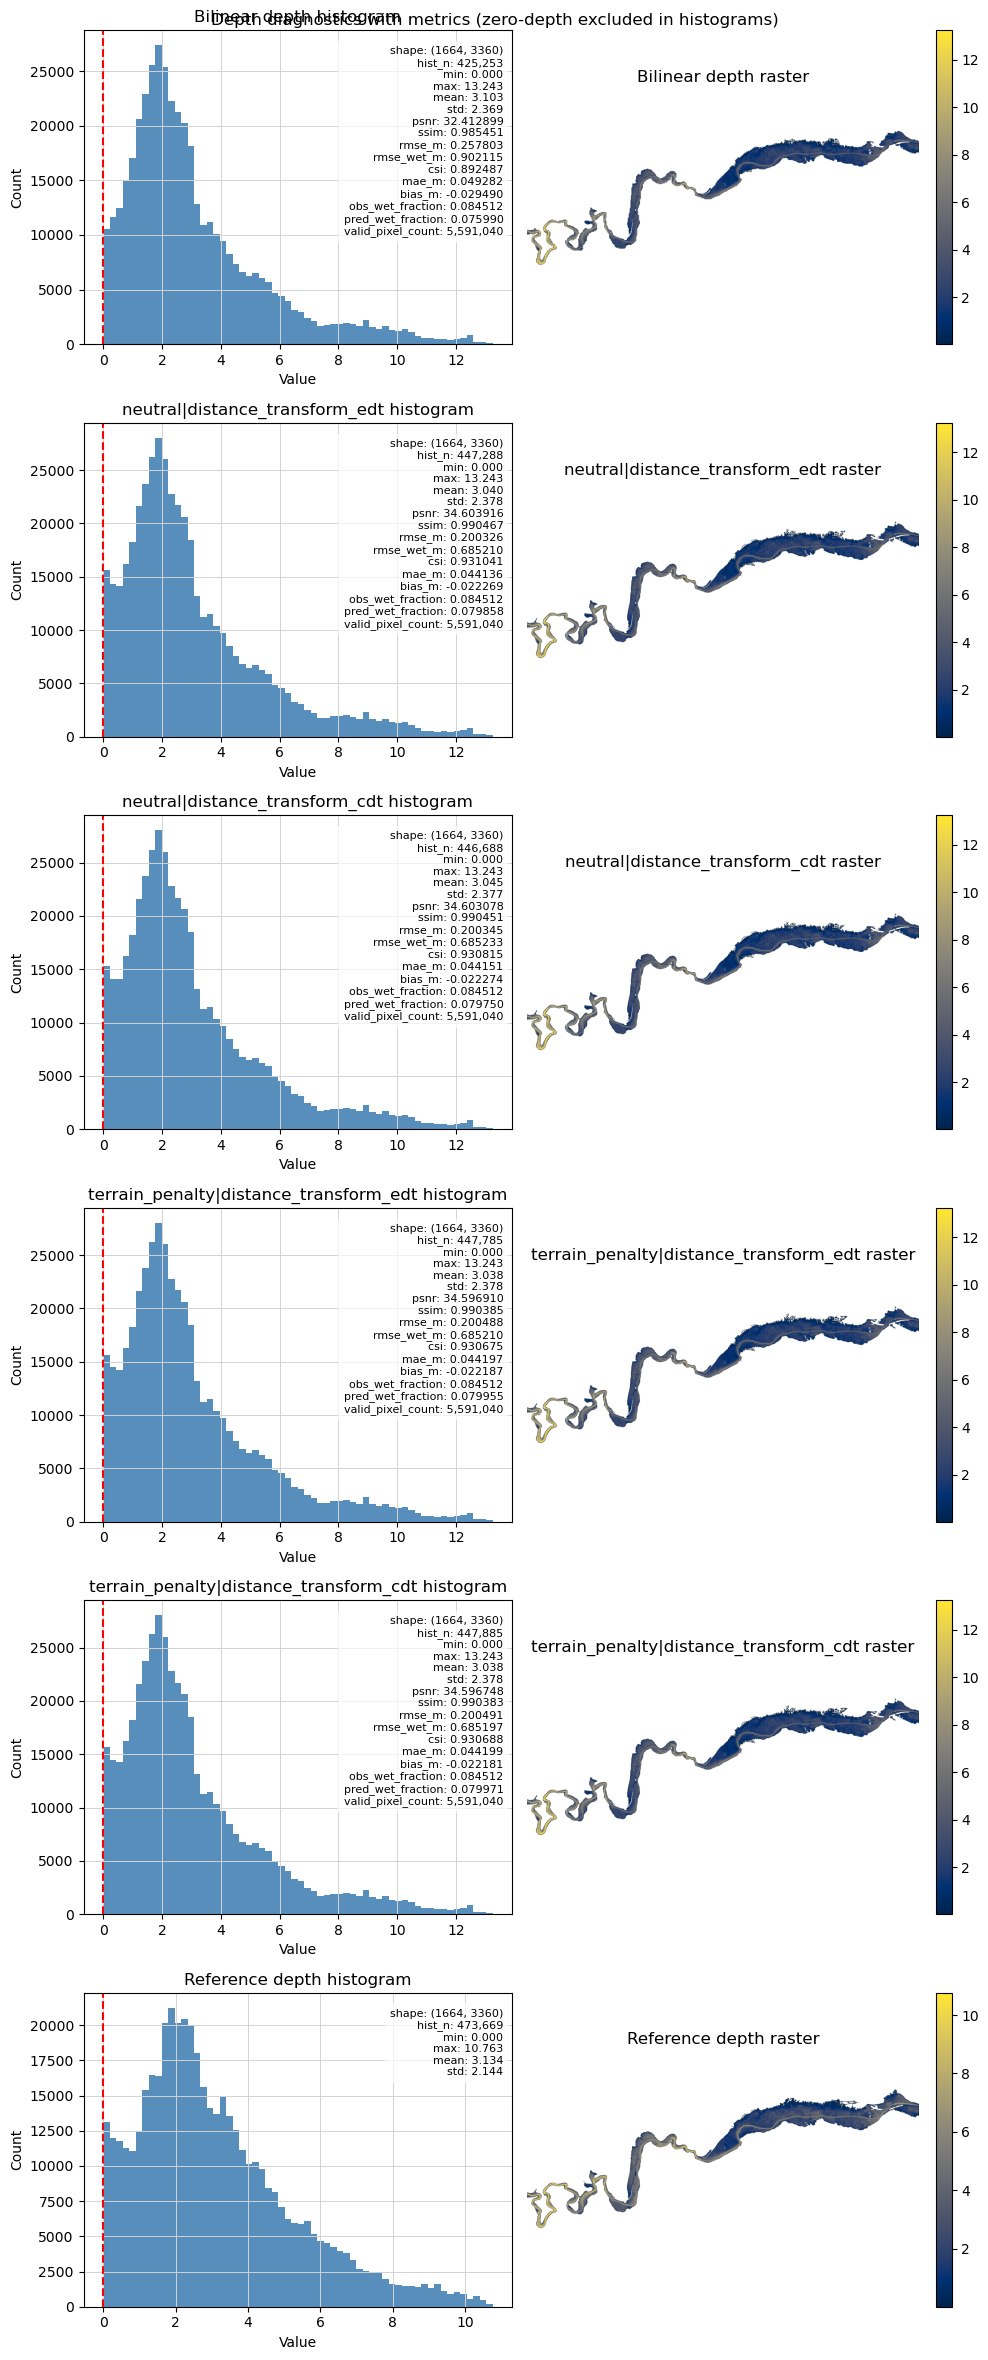

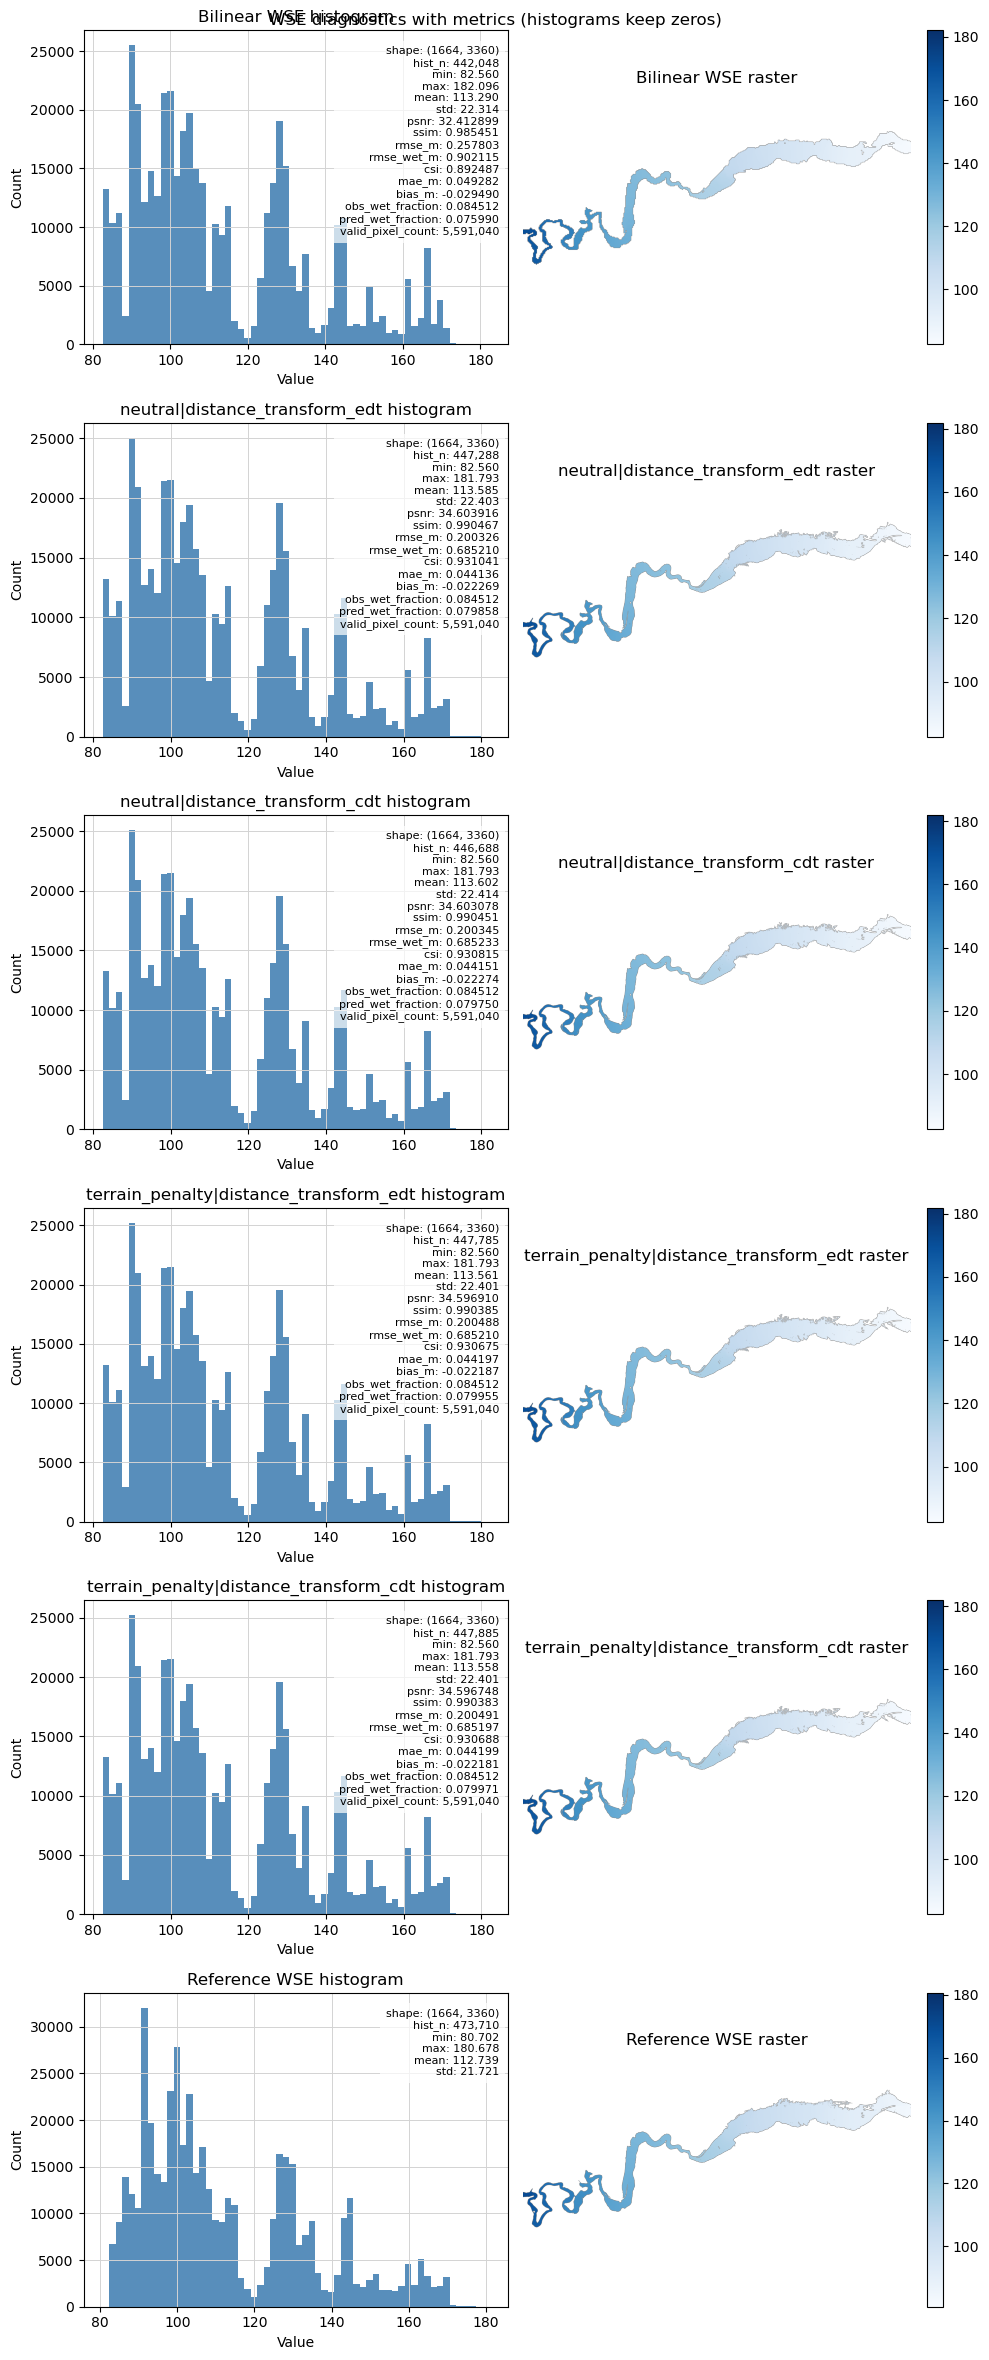

In [7]:
ok_run_names = summary_df.loc[summary_df["status"] == "ok", "run_name"].tolist()
print(f"successful runs: {len(ok_run_names)}/{len(ensemble_plan_df)}")

# Depth plot: zeros are masked in histograms by plot_hist_raster_grid(is_depth=True).
depth_plot_specs = [
    {
        "name": "Bilinear depth",
        "arr": bilinear_depth,
        "cmap": "cividis",
        "use_dry_mask": True,
        "dry_thresh": CSI_THRESH_M,
        "is_depth": True,
        "metric_key": "Bilinear",
    },
]
for run_name in ok_run_names:
    depth_plot_specs.append(
        {
            "name": run_name,
            "arr": pred_depth_by_name[run_name],
            "cmap": "cividis",
            "use_dry_mask": True,
            "dry_thresh": CSI_THRESH_M,
            "is_depth": True,
            "metric_key": run_name,
        }
    )

depth_plot_specs.append(
    {
        "name": "Reference depth",
        "arr": valid_depth,
        "cmap": "cividis",
        "use_dry_mask": True,
        "dry_thresh": CSI_THRESH_M,
        "is_depth": True,
        "metric_key": None,
    }
)

plot_hist_raster_grid(
    plot_specs=depth_plot_specs,
    title="Depth diagnostics with metrics (zero-depth excluded in histograms)",
    bins=60,
    metrics_df=metrics_df,
)

# WSE plot: zeros are not masked in histograms (is_depth=False).
wse_plot_specs = [
    {
        "name": "Bilinear WSE",
        "arr": pred_wse_by_name["Bilinear"],
        "cmap": "Blues",
        "use_dry_mask": False,
        "dry_thresh": None,
        "is_depth": False,
        "metric_key": "Bilinear",
    },
]
for run_name in ok_run_names:
    wse_plot_specs.append(
        {
            "name": run_name,
            "arr": pred_wse_by_name[run_name],
            "cmap": "Blues",
            "use_dry_mask": False,
            "dry_thresh": None,
            "is_depth": False,
            "metric_key": run_name,
        }
    )

wse_plot_specs.append(
    {
        "name": "Reference WSE",
        "arr": wse_reference_xr.data,
        "cmap": "Blues",
        "use_dry_mask": False,
        "dry_thresh": None,
        "is_depth": False,
        "metric_key": None,
    }
)

plot_hist_raster_grid(
    plot_specs=wse_plot_specs,
    title="WSE diagnostics with metrics (histograms keep zeros)",
    bins=60,
    metrics_df=metrics_df,
)


## 7) Performance Summary

In [9]:
ok_summary_df = summary_df[summary_df["status"] == "ok"].copy()

rank_cols = [
    "run_name",
    "distance_fill",
    "distance_fill_method",
    "wall_seconds",
    "rmse_m",
    "rmse_wet_m",
    "mae_m",
    "bias_m",
    "csi",
    "psnr",
    "ssim",
    "pred_wet_fraction",
]

print("Top runs by RMSE (lower is better):")
ok_summary_df.sort_values(["rmse_m", "wall_seconds"])[rank_cols].head(len(ok_summary_df)).round(6)

print("Top runs by runtime (faster is better):")
ok_summary_df.sort_values(["wall_seconds", "rmse_m"])[rank_cols].head(len(ok_summary_df)).round(6)

if len(ok_summary_df):
    best_rmse = ok_summary_df.sort_values(["rmse_m", "wall_seconds"]).iloc[0]
    best_speed = ok_summary_df.sort_values(["wall_seconds", "rmse_m"]).iloc[0]

    print("\n\nbest accuracy run:")
    print(best_rmse[rank_cols].to_string())

    print("\n\nfastest run:")
    print(best_speed[rank_cols].to_string())
else:
    print("No successful runs to summarize.")


Top runs by RMSE (lower is better):
Top runs by runtime (faster is better):


best accuracy run:
run_name                neutral|distance_transform_edt
distance_fill                                  neutral
distance_fill_method            distance_transform_edt
wall_seconds                                  2.040352
rmse_m                                        0.200326
rmse_wet_m                                     0.68521
mae_m                                         0.044136
bias_m                                       -0.022269
csi                                           0.931041
psnr                                         34.603916
ssim                                          0.990467
pred_wet_fraction                             0.079858


fastest run:
run_name                neutral|distance_transform_cdt
distance_fill                                  neutral
distance_fill_method            distance_transform_cdt
wall_seconds                                  1.808389
rmse_m  

## 8) Artifacts

- Plan: `misc/_outputs/CostGrow_experiment/ensemble_plan.csv`
- Runtime: `misc/_outputs/CostGrow_experiment/ensemble_runtime.csv`
- Metrics table: `misc/_outputs/CostGrow_experiment/ensemble_metrics_table.csv`
- Joined summary: `misc/_outputs/CostGrow_experiment/ensemble_summary.csv`
